# Crime Change Over Time (Month/Year)
This notebook explores the question: **"Does crime change over time in relation to month/year?"** using the cleaned crime dataset.

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load the cleaned dataset
data_path = '../data/processed/tops_crime_data_cleaned.csv'
df = pd.read_csv(data_path)

# Display the first few rows to verify successful load
df.head()

,CREATE_TIME_INCIDENT,DISPO_TEXT,LOCATION_TEXT,Latitude,Longitude
0,2025-10-13 12:15:08,COMMUNITY POLICING,SAMMONS MEDIA,30.452343,-84.278508
1,2025-10-13 14:31:26,MISC SERVICE CALL,NaN,30.405325,-84.394920
2,2025-04-10 16:15:18,MISC SERVICE CALL,NaN,30.527557,-84.220477
3,2025-05-20 14:29:41,MISC SERVICE CALL,NaN,30.438515,-84.299572
4,2025-10-14 08:27:37,TRESPASSING,NaN,30.444864,-84.292854


In [4]:
# Convert 'CREATE_TIME_INCIDENT' from string to datetime objects
df['CREATE_TIME_INCIDENT'] = pd.to_datetime(df['CREATE_TIME_INCIDENT'], errors='coerce')

# Drop rows where datetime parsing failed, if any
df = df.dropna(subset=['CREATE_TIME_INCIDENT'])

# Extract Year and Month to a new column (as a Period for easy grouping)
df['YearMonth'] = df['CREATE_TIME_INCIDENT'].dt.to_period('M')

df.head()

,CREATE_TIME_INCIDENT,DISPO_TEXT,LOCATION_TEXT,Latitude,Longitude,YearMonth
0,2025-10-13 12:15:08,COMMUNITY POLICING,SAMMONS MEDIA,30.452343,-84.278508,2025-10
1,2025-10-13 14:31:26,MISC SERVICE CALL,NaN,30.405325,-84.394920,2025-10
2,2025-04-10 16:15:18,MISC SERVICE CALL,NaN,30.527557,-84.220477,2025-04
3,2025-05-20 14:29:41,MISC SERVICE CALL,NaN,30.438515,-84.299572,2025-05
4,2025-10-14 08:27:37,TRESPASSING,NaN,30.444864,-84.292854,2025-10


In [5]:
# Group the dataset by 'YearMonth' and count the frequency of incidents
crime_trend = df.groupby('YearMonth').size().reset_index(name='Incident_Count')

# Convert 'YearMonth' back to a timestamp so it plots nicely on an axis
crime_trend['Date'] = crime_trend['YearMonth'].dt.to_timestamp()

crime_trend.head()

,YearMonth,Incident_Count,Date
0,2025-03,8907,2025-03-01
1,2025-04,13504,2025-04-01
2,2025-05,13802,2025-05-01
3,2025-06,12893,2025-06-01
4,2025-07,13741,2025-07-01


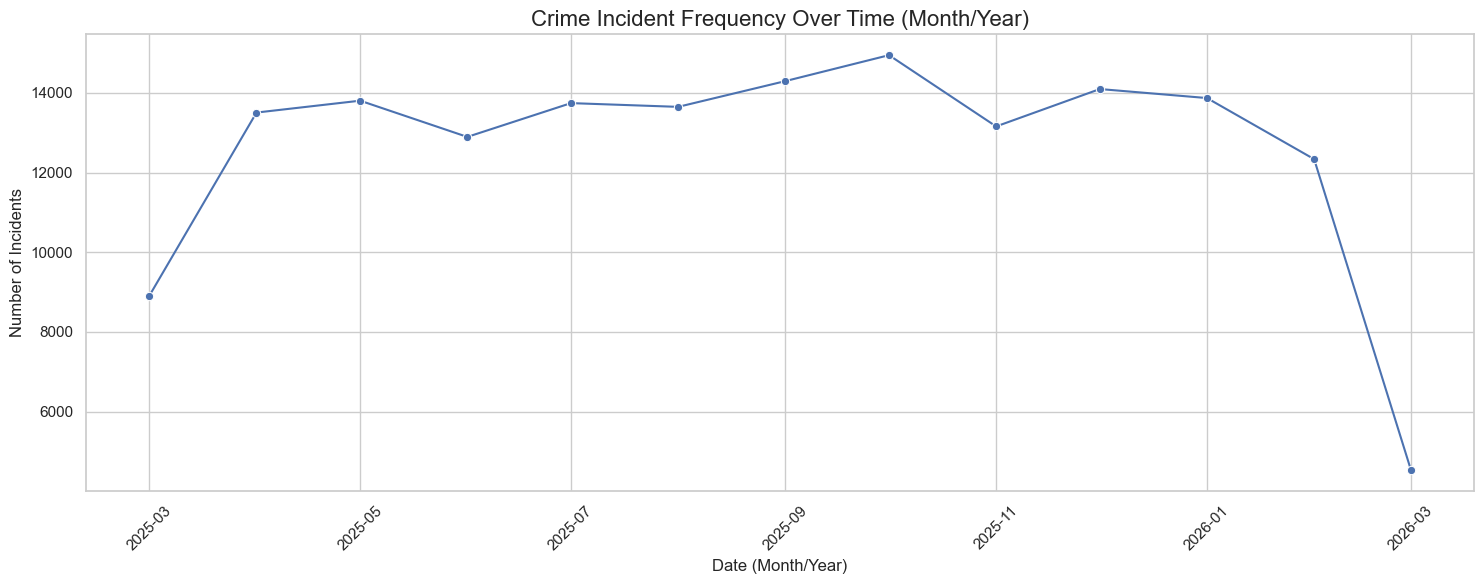

In [9]:
import os

# Plot the trend of crime incidents over time
plt.figure(figsize=(15, 6))
sns.lineplot(data=crime_trend, x='Date', y='Incident_Count', marker='o')

plt.title('Crime Incident Frequency Over Time (Month/Year)', fontsize=16)
plt.xlabel('Date (Month/Year)', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()

# Ensure the figures directory exists
os.makedirs('../figures', exist_ok=True)

# Save the plot before showing it
plt.savefig('../figures/incidents_over_time.png', dpi=300)
plt.show()

In [ ]:
# --- Descriptive statistics (overall) ---
# Ensure datetime features exist for exploration
df['Hour'] = df['CREATE_TIME_INCIDENT'].dt.hour
df['DayOfWeek'] = df['CREATE_TIME_INCIDENT'].dt.dayofweek
df['Month'] = df['CREATE_TIME_INCIDENT'].dt.month
df['Year'] = df['CREATE_TIME_INCIDENT'].dt.year

key_numeric_cols = ['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'Year']

print("Overall descriptive statistics:")
print(df[key_numeric_cols].describe())

print("\nExplicit statistics for key numeric columns:")
for col in key_numeric_cols:
    s = df[col].dropna()
    print(
        f"{col}: mean={s.mean():.4f}, median={s.median():.4f}, "
        f"min={s.min():.4f}, max={s.max():.4f}, std={s.std():.4f}"
    )

# --- Descriptive stats by group (categorical variable: DISPO_TEXT) ---
top_dispo = df['DISPO_TEXT'].value_counts().head(10).index
group_stats = (
    df[df['DISPO_TEXT'].isin(top_dispo)]
    .groupby('DISPO_TEXT')
    .agg(
        Incident_Count=('DISPO_TEXT', 'size'),
        Lat_Mean=('Latitude', 'mean'),
        Lat_Median=('Latitude', 'median'),
        Lat_Std=('Latitude', 'std'),
        Lon_Mean=('Longitude', 'mean'),
        Lon_Median=('Longitude', 'median'),
        Lon_Std=('Longitude', 'std'),
    )
    .sort_values('Incident_Count', ascending=False)
)
print("\nGrouped descriptive stats (top 10 DISPO_TEXT):")
print(group_stats)

# --- Correlation analysis ---
corr_cols = ['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix (Selected Numeric Features)')
plt.tight_layout()
plt.show()

# --- Question 1: Do weekend days have different incident volumes than weekdays? ---
daily = df.copy()
daily['DateOnly'] = daily['CREATE_TIME_INCIDENT'].dt.floor('D')
daily['IsWeekend'] = daily['CREATE_TIME_INCIDENT'].dt.dayofweek >= 5

daily_counts = (
    daily.groupby(['DateOnly', 'IsWeekend'])
    .size()
    .reset_index(name='Incident_Count')
)

weekend_summary = daily_counts.groupby('IsWeekend')['Incident_Count'].agg(['mean', 'median', 'min', 'max', 'std', 'count'])
weekend_summary.index = ['Weekday', 'Weekend']
print("\nQ1 - Daily incident volume: Weekday vs Weekend")
print(weekend_summary)

plt.figure(figsize=(6, 4))
sns.boxplot(data=daily_counts, x='IsWeekend', y='Incident_Count')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title('Daily Incident Count: Weekday vs Weekend')
plt.xlabel('')
plt.tight_layout()
plt.show()

# --- Question 2: Which incident categories are consistently high over time? ---
top5_categories = df['DISPO_TEXT'].value_counts().head(5).index
monthly_top = (
    df[df['DISPO_TEXT'].isin(top5_categories)]
    .groupby(['YearMonth', 'DISPO_TEXT'])
    .size()
    .reset_index(name='Incident_Count')
)
monthly_top['Date'] = monthly_top['YearMonth'].dt.to_timestamp()

print("\nQ2 - Top 5 incident categories by total volume:")
print(df['DISPO_TEXT'].value_counts().head(5))

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_top, x='Date', y='Incident_Count', hue='DISPO_TEXT', marker='o')
plt.title('Monthly Trend for Top 5 Incident Categories')
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()